<div style="background: linear-gradient(135deg, #0072B2 0%, #004f7a 100%); color: #ffffff; padding: 32px 38px; border-radius: 12px; margin: 0 0 22px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;"><div style="font-size: 11px; letter-spacing: 2.5px; text-transform: uppercase; opacity: 0.75; margin-bottom: 6px; font-weight: 500;">Analyse de Données avec Python pour Professionnels de la Santé</div><h1 style="margin: 0; font-size: 30px; font-weight: 600; color: #ffffff; line-height: 1.2; border: none; padding: 0;"><span style="opacity: 0.65; font-weight: 400;">Module 4</span><span style="opacity: 0.4; margin: 0 12px;">·</span>Tests d'hypothèses</h1><div style="margin-top: 14px; font-size: 14px; opacity: 0.9;">Version condensee 6 heures  ·  Module 4 sur 6  ·  Duree 60 minutes</div></div><div style="margin: 0 0 22px 0;"><span style="display: inline-block; background: #e8f4f8; color: #005c8f; padding: 5px 14px; border-radius: 14px; font-size: 12px; margin: 0 6px 6px 0; font-weight: 500; border: 1px solid #b8dde9; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">Niveau intermediaire</span><span style="display: inline-block; background: #fff4eb; color: #a64a00; padding: 5px 14px; border-radius: 14px; font-size: 12px; margin: 0 6px 6px 0; font-weight: 500; border: 1px solid #f0c89d; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">Duree 60 min</span><span style="display: inline-block; background: #f5f0fa; color: #5a3380; padding: 5px 14px; border-radius: 14px; font-size: 12px; margin: 0 6px 6px 0; font-weight: 500; border: 1px solid #d4c0e8; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">Prerequis : Modules 1, 2</span><span style="display: inline-block; background: #f3f3f3; color: #555555; padding: 5px 14px; border-radius: 14px; font-size: 12px; margin: 0 6px 6px 0; font-weight: 500; border: 1px solid #d0d0d0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">Colab compatible</span></div><div style="margin: 0 0 18px 0;"><a href="https://colab.research.google.com/github/gabayae/-python-sante/blob/main/notebooks_vierges/module_04_tests_hypotheses.ipynb" target="_blank" style="text-decoration: none;"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" style="vertical-align: middle;"/></a></div><div style="border: 1px solid #e0e0e0; border-left: 4px solid #009E73; background: #fafbfc; padding: 18px 22px; margin: 20px 0; border-radius: 0 6px 6px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;"><div style="font-size: 11px; letter-spacing: 1.5px; color: #009E73; font-weight: 600; margin-bottom: 10px;">OBJECTIFS DU MODULE</div><ul style="margin: 0; padding-left: 22px; color: #333; font-size: 14px;"><li style="margin: 6px 0; line-height: 1.5;">Enoncer correctement une hypothèse nulle H0 et alternative H1.</li><li style="margin: 6px 0; line-height: 1.5;">Choisir le bon test selon la question : <strong>t de Student (un / deux échantillons / apparie), chi-deux, Mann-Whitney U</strong>.</li><li style="margin: 6px 0; line-height: 1.5;">Verifier les conditions et choisir une alternative non parametrique quand elles echouent.</li><li style="margin: 6px 0; line-height: 1.5;">Interpreter une <strong>p-value</strong> correctement et la rapporter avec une <strong>taille d'effet</strong> et un <strong>intervalle de confiance</strong>.</li><li style="margin: 6px 0; line-height: 1.5;">Appliquer une <strong>correction pour tests multiples</strong> (Bonferroni, Benjamini-Hochberg).</li><li style="margin: 6px 0; line-height: 1.5;">Distinguer significativite <strong>statistique</strong> vs <strong>clinique</strong>.</li></ul></div><div style="border-left: 4px solid #0072B2; background: #f0f7fb; padding: 14px 18px; margin: 18px 0; border-radius: 0 6px 6px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;"><div style="font-weight: 600; color: #005c8f; font-size: 11px; letter-spacing: 1.2px; margin-bottom: 6px;">JEU DE DONNÉES</div><div style="color: #333; font-size: 14px; line-height: 1.5;">Extrait pedagogique de l'étude <strong>Framingham</strong> (cohorte cardiovasculaire de reference, suivie depuis 1948). Variable d'interet : <code>TenYearCHD</code> (1 = événement coronarien dans les 10 ans).<br><br>Source du fichier : <a href="https://github.com/GauravPadawe/Framingham-Heart-Study" target="_blank">GauravPadawe/Framingham-Heart-Study</a>.</div></div>

## 0. Imports et reproductibilité

> **Syntaxe — import depuis un sous-module**
> ```python
> from scipy import stats              # tout le sous-module
> from statsmodels.stats.multitest import multipletests   # une fonction
> ```

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats                                    # tests statistiques
from statsmodels.stats.multitest import multipletests      # corrections multiples

np.random.seed(42)
sns.set_theme(style="whitegrid", font_scale=1.05)

## 1. La logique d'un test d'hypothèse

Un test est une **preuve par contradiction probabiliste** :

1. On suppose **H0 vraie** (pas d'effet).
2. On calcule une statistique de test a partir des données.
3. On demande : *si H0 etait vraie, ces données seraient-elles inhabituelles ?*
Cette probabilité est la **p-value**.
4. Si p < seuil $\alpha$ (souvent 0,05), on **rejette H0**.

### Ce qu'une p-value n'est PAS

- Pas la probabilité que H0 soit vraie.
- Pas la probabilité que le résultat soit du au hasard.
- Ne mesure pas la **taille** d'un effet.
- p = 0,049 n'est pas notablement différent de p = 0,051.

> **Regle.** Rapporter une p-value avec une **taille d'effet** et un **IC**. Une étude de 100 000 patients peut détecter $d = 0{,}05$ avec $p < 10^{-6}$ : statistiquement significatif, cliniquement non pertinent.

Reference : Wasserstein RL & Lazar NA, *The ASA Statement on p-Values: Context, Process, and Purpose*, The American Statistician 70(2), 2016.

## 2. Test t a un échantillon

**Question.** La moyenne du cholesterol dans notre clinique differe-t-elle de la moyenne nationale de 200 mg/dL ?

- H0 : $\mu = 200$
- H1 : $\mu \neq 200$

Hypothese : la moyenne d'échantillonnage est approximativement normale (garantie par le TCL si $n > 30$, exige une distribution normale sinon).

> **Syntaxe — test t un échantillon**
> ```python
> t, p = stats.ttest_1samp(échantillon, popmean=valeur_h0)
> # t : statistique de test
> # p : p-value bilaterale
> ```

In [2]:
# Simulation : moyenne 212, écart-type 35, n = 80
chol = np.random.normal(212, 35, size=80)

# Test : moyenne differe-t-elle de 200 ?
t, p = stats.ttest_1samp(chol, popmean=200)

# Calculer l'IC 95% manuellement (scipy ne le donne pas directement ici)
# stats.sem = standard error of mean = écart-type / sqrt(n)
moy = chol.mean()
se = stats.sem(chol)
# stats.t.ppf(p, df) = quantile p de la loi de Student a df degres
ic = moy + np.array([-1, 1]) * stats.t.ppf(0.975, df=len(chol) - 1) * se

print(f"Moyenne échantillon : {moy:.1f} mg/dL")
print(f"IC 95%              : [{ic[0]:.1f}, {ic[1]:.1f}]")
print(f"t (df={len(chol)-1})         : {t:.3f}")
print(f"p-value             : {p:.4f}")

Moyenne échantillon : 207.7 mg/dL
IC 95%              : [200.2, 215.1]
t (df=79)         : 2.046
p-value             : 0.0441


## 3. Test t pour deux échantillons indépendants

**Question.** Le traitement abaisse-t-il la tension par rapport au placebo ?

Hypotheses :

1. Echantillons **indépendants** ;
2. Variable approximativement **normale** dans chaque groupe ;
3. **Variances egales** — relachee par la correction de **Welch** (`equal_var=False`, défaut moderne).

> **Syntaxe — test t deux échantillons**
> ```python
> t, p = stats.ttest_ind(groupe1, groupe2,
>                        equal_var=False)   # Welch (recommandé par défaut)
> ```

In [3]:
# Deux groupes simules
traitement = np.random.normal(128, 15, size=60)
controle   = np.random.normal(138, 16, size=55)

# Test t de Welch (variances inégales autorisees)
t, p = stats.ttest_ind(traitement, controle, equal_var=False)

print(f"Moyenne traitement : {traitement.mean():.1f} mmHg")
print(f"Moyenne controle   : {controle.mean():.1f} mmHg")
print(f"Difference         : {controle.mean() - traitement.mean():.1f} mmHg")
print(f"t de Welch         : {t:.3f}")
print(f"p-value            : {p:.4f}")

Moyenne traitement : 127.5 mmHg
Moyenne controle   : 139.5 mmHg
Difference         : 11.9 mmHg
t de Welch         : -4.460
p-value            : 0.0000


## 4. Test t apparie (avant / après)

**Question.** Un programme d'exercice de 12 semaines réduit-il la tension systolique ? Chaque patient est **son propre temoin**.

Le test utilise les **différences intra-patient**, eliminant la variabilite inter-patient.

> **Syntaxe — test t apparie**
> ```python
> t, p = stats.ttest_rel(avant, après)    # rel = related/paired
> # Les deux tableaux DOIVENT être alignes patient par patient.
> ```

In [4]:
n = 45
avant  = np.random.normal(142, 12, n)             # tension avant
après  = avant - np.random.normal(8, 6, n)        # tension après (moins ~8 mmHg)
diff   = avant - après                            # réduction par patient

t, p = stats.ttest_rel(avant, après)

print(f"Moyenne avant     : {avant.mean():.1f} mmHg")
print(f"Moyenne après     : {après.mean():.1f} mmHg")
print(f"Reduction moyenne : {diff.mean():.1f} mmHg")
print(f"t apparie (df={n-1}): {t:.3f}")
print(f"p-value           : {p:.2e}")    # notation scientifique

Moyenne avant     : 143.6 mmHg
Moyenne après     : 135.8 mmHg
Reduction moyenne : 7.9 mmHg
t apparie (df=44): 7.798
p-value           : 7.89e-10


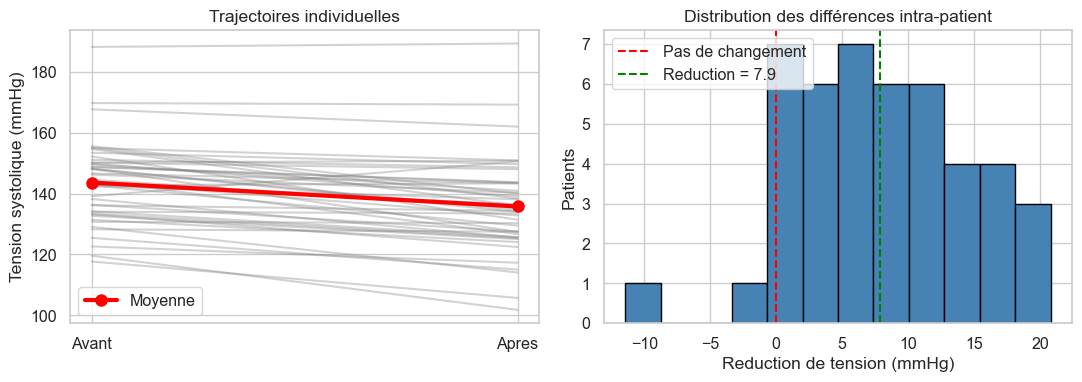

In [5]:
# Visualisation : trajectoires individuelles + distribution des différences
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Lignes grises : une par patient (spaghetti plot)
for i in range(n):
    axes[0].plot([0, 1], [avant[i], après[i]],
                 color="gray", alpha=0.35)
# Ligne rouge : la moyenne du groupe
axes[0].plot([0, 1], [avant.mean(), après.mean()],
             color="red", lw=3, marker="o", markersize=8, label="Moyenne")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Avant", "Apres"])
axes[0].set_ylabel("Tension systolique (mmHg)")
axes[0].set_title("Trajectoires individuelles")
axes[0].legend()

# Distribution des différences intra-patient
axes[1].hist(diff, bins=12, edgecolor="black", color="steelblue")
axes[1].axvline(0, color="red", ls="--", label="Pas de changement")
axes[1].axvline(diff.mean(), color="green", ls="--",
                label=f"Reduction = {diff.mean():.1f}")
axes[1].set_xlabel("Reduction de tension (mmHg)")
axes[1].set_ylabel("Patients")
axes[1].set_title("Distribution des différences intra-patient")
axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Test du chi-deux d'indépendance

**Question.** La prévalence du diabète est-elle associee a la catégorie d'IMC ?

Compare les comptages **observes** dans un tableau de contingence aux comptages **attendus** sous independance.

$$\chi^2 = \sum_{ij} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

Hypothese : chaque effectif attendu $\ge 5$. Sinon utiliser le test **exact de Fisher** (`stats.fisher_exact`).

> **Syntaxe — chi-deux**
> ```python
> tab = pd.crosstab(df["ligne"], df["colonne"])   # contingence
> chi2, p, dof, attendu = stats.chi2_contingency(tab)
> # chi2    : statistique
> # p       : p-value
> # dof     : degres de liberte = (n_lignes - 1) * (n_colonnes - 1)
> # attendu : matrice des effectifs attendus sous H0
> ```

In [6]:
# Simulation : 500 patients, repartis selon l'IMC
n = 500
imc_cat = np.random.choice(["Normal", "Surpoids", "Obesite"],
                          size=n, p=[0.3, 0.4, 0.3])

# Probabilite de diabète dependant de la catégorie d'IMC
p_diab = {"Normal": 0.08, "Surpoids": 0.18, "Obesite": 0.35}

# np.random.binomial(1, p) tire 0 ou 1 avec probabilité p
# List comprehension : une boucle inline qui construit une liste
diab = np.array([np.random.binomial(1, p_diab[b]) for b in imc_cat])

# np.where(condition, valeur_si_True, valeur_si_False) : vectorise un if/else
df = pd.DataFrame({
    "imc":      imc_cat,
    "diabète": np.where(diab == 1, "Oui", "Non"),
})

# Table de contingence puis test
tab = pd.crosstab(df["imc"], df["diabète"])
print(tab)

chi2, p, dof, attendu = stats.chi2_contingency(tab)
print(f"\nchi2 = {chi2:.2f}, df = {dof}, p = {p:.2e}")
print("\nEffectifs attendus sous H0 (independance) :")
print(pd.DataFrame(attendu, index=tab.index, columns=tab.columns).round(1))

diabète   Non  Oui
imc               
Normal    137   14
Obesite   101   51
Surpoids  160   37

chi2 = 28.03, df = 2, p = 8.20e-07

Effectifs attendus sous H0 (independance) :
diabète     Non   Oui
imc                  
Normal    120.2  30.8
Obesite   121.0  31.0
Surpoids  156.8  40.2


## 6. Mann-Whitney U — alternative non parametrique

Quand la variable est asymétrique (duree de sejour, couts, biologie avec longue queue) ou que $n$ est petit, le test t sur l'échelle brute peut induire en erreur.

Mann-Whitney U compare les **rangs** : il teste si une distribution domine stochastiquement l'autre.

> **Syntaxe**
> ```python
> u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
> ```

In [7]:
# Duree de sejour : exponentielle a droite (asymétrique)
dms_chir = np.random.exponential(7,   size=40)    # moyenne 7 j
dms_med  = np.random.exponential(4.5, size=45)    # moyenne 4.5 j

u, p = stats.mannwhitneyu(dms_chir, dms_med, alternative="two-sided")

# np.median plus informatif que mean pour une distribution asymétrique
print(f"DMS mediane (chirurgie) : {np.median(dms_chir):.1f} j")
print(f"DMS mediane (medecine)  : {np.median(dms_med):.1f} j")
print(f"U = {u:.0f}, p = {p:.4f}")

DMS mediane (chirurgie) : 4.0 j
DMS mediane (medecine)  : 3.3 j
U = 1016, p = 0.3092


## 7. Correction pour tests multiples

Si vous testez **20 hypothèses indépendantes** au seuil 0,05 sous H0, vous attendez **1 faux positif** par hasard.

Deux familles de corrections :

- **Bonferroni** (contrôle FWER) — multiplie chaque p par $m$. Tres conservateur ; a utiliser quand même **un** faux positif est inacceptable.
- **Benjamini-Hochberg FDR** — contrôle la proportion attendue de faux positifs parmi les positifs declares. Standard en genomique et en analyses exploratoires.

> **Syntaxe**
> ```python
> from statsmodels.stats.multitest import multipletests
> rejette, p_corr, _, _ = multipletests(p_array, alpha=0.05,
>                                       method="bonferroni")
> # rejette : tableau de True/False
> # p_corr  : p-values corrigees
> ```

In [8]:
# Simulation : 1000 tests sous H0 (rien a trouver)
n_tests = 1000
pvals = np.empty(n_tests)                # tableau vide de longueur 1000

# Boucle : 1000 paires de groupes tirees de N(0, 1) - H0 vraie
for i in range(n_tests):
    a = np.random.normal(0, 1, 30)
    b = np.random.normal(0, 1, 30)
    pvals[i] = stats.ttest_ind(a, b).pvalue

# Sans correction
n_fp = (pvals < 0.05).sum()        # comptage vectorise
print(f"Sans correction : {n_fp} significatifs sur {n_tests}  ({n_fp / n_tests:.1%})")

# Avec corrections (4 valeurs renvoyees, on ignore les 2 dernieres avec _)
rej_bonf, _, _, _ = multipletests(pvals, alpha=0.05, method="bonferroni")
rej_fdr,  _, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
print(f"Bonferroni      : {rej_bonf.sum()} significatifs")
print(f"FDR (BH)        : {rej_fdr.sum()} significatifs")

Sans correction : 44 significatifs sur 1000  (4.4%)
Bonferroni      : 0 significatifs
FDR (BH)        : 0 significatifs


## 8. Taille d'effet — d de Cohen

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{pooled}}$$

Reperes (Cohen 1988, indicatifs) :

- $|d| < 0{,}2$ — negligeable
- $0{,}2 \le |d| < 0{,}5$ — petit
- $0{,}5 \le |d| < 0{,}8$ — moyen
- $|d| \ge 0{,}8$ — large

> **Syntaxe — opérateur ternaire (if inline)**
> ```python
> x = "a" if condition else "b"     # équivalent a if/else en une ligne
> ```

In [9]:
def cohens_d(g1, g2):
    """d de Cohen pour deux groupes indépendants."""
    n1, n2 = len(g1), len(g2)
    # ddof=1 : variance d'échantillon (denominateur n-1, pas n)
    s = math.sqrt(((n1 - 1) * np.var(g1, ddof=1) + (n2 - 1) * np.var(g2, ddof=1))
                  / (n1 + n2 - 2))
    return (g1.mean() - g2.mean()) / s

# Reutiliser les groupes du paragraphe 3
d = cohens_d(traitement, controle)

# Chaine de if/else inline (lecture droite a gauche)
label = ("large" if abs(d) >= 0.8 else
         "moyen" if abs(d) >= 0.5 else
         "petit" if abs(d) >= 0.2 else "negligeable")
print(f"d de Cohen (traitement vs controle) : {d:.2f} ({label})")

d de Cohen (traitement vs controle) : -0.83 (large)


In [10]:
# Mise en garde : grand n + petit effet = p minuscule
huge1 = np.random.normal(120.0, 15, size=50_000)
huge2 = np.random.normal(120.5, 15, size=50_000)   # différence réelle de 0.5 mmHg

t, p = stats.ttest_ind(huge1, huge2)
print(f"Diff moyenne : {huge2.mean() - huge1.mean():.2f} mmHg")
print(f"p-value      : {p:.2e}")
print(f"d de Cohen   : {cohens_d(huge1, huge2):.3f}")
print("  -> Statistiquement significatif. Cliniquement non pertinent.")

Diff moyenne : 0.63 mmHg
p-value      : 2.89e-11
d de Cohen   : -0.042
  -> Statistiquement significatif. Cliniquement non pertinent.


## 9. Application — Framingham

Source : [GitHub - GauravPadawe/Framingham-Heart-Study](https://github.com/GauravPadawe/Framingham-Heart-Study).

> **Syntaxe — dropna avec subset**
> ```python
> df.dropna()                              # supprime toute ligne avec NaN
> df.dropna(subset=["col"])                # seulement si NaN dans col
> df.copy()                                # bonne pratique après filtrage
> ```

In [11]:
import os
from pathlib import Path
import pandas as pd

# Chemins de cache candidats, dans l'ordre :
#   1. ./data/         (jupyter local, notebook a la racine)
#   2. ../data/        (jupyter local, notebook dans un sous-dossier)
#   3. ./             (au pire on cree un cache dans le cwd)
# En Colab, aucun n'existe : on tombe sur l'URL et on cree ./data/ pour les
# cellules suivantes.
_CANDIDATES = [Path("data"), Path("../data")]
DATA_DIR = next((p for p in _CANDIDATES if p.is_dir()), Path("data"))
DATA_DIR.mkdir(exist_ok=True)


def load_csv(name: str, url: str, **read_csv_kwargs) -> pd.DataFrame:
    """Charge un CSV : cache local d'abord, sinon URL publique.

    Le cache utilise le meme separateur que la lecture (TSV reste TSV).
    """
    for candidate_dir in _CANDIDATES:
        local = candidate_dir / name
        if local.exists():
            return pd.read_csv(local, **read_csv_kwargs)
    df = pd.read_csv(url, **read_csv_kwargs)
    try:
        sep = read_csv_kwargs.get("sep", ",")
        (DATA_DIR / name).parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(DATA_DIR / name, index=False, sep=sep)
    except OSError:
        pass
    return df

FRAM_URL = (
    "https://raw.githubusercontent.com/GauravPadawe/"
    "Framingham-Heart-Study/master/framingham.csv"
)
fram = load_csv("framingham.csv", FRAM_URL)

# .dropna() supprime TOUTE ligne avec au moins 1 NaN
# Approche grossiere mais didactique - en pratique on imputerait
fram_clean = fram.dropna().copy()

print(f"Dimensions (complet)   : {fram_clean.shape}")
print(f"Prevalence CHD 10 ans : {fram_clean['TenYearCHD'].mean():.1%}")
fram_clean.head()

Dimensions (complet)   : (3658, 16)
Prevalence CHD 10 ans : 15.2%


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 10. Exercices (avec corriges)


### Exercice 1 — Test t a deux échantillons sur `sysBP` selon `TenYearCHD`

In [12]:
# Votre essai ici


In [13]:
# Solution
# .loc[ligne, colonne] : sélection precise par étiquette
chd  = fram_clean.loc[fram_clean["TenYearCHD"] == 1, "sysBP"]
ctrl = fram_clean.loc[fram_clean["TenYearCHD"] == 0, "sysBP"]

t, p = stats.ttest_ind(chd, ctrl, equal_var=False)
# .values pour convertir pd.Series -> np.array (cohens_d attend du numpy)
d = cohens_d(chd.values, ctrl.values)

print(f"Moyenne SBP, CHD = 1 : {chd.mean():.1f}")
print(f"Moyenne SBP, CHD = 0 : {ctrl.mean():.1f}")
print(f"Difference            : {chd.mean() - ctrl.mean():.1f} mmHg")
print(f"t = {t:.2f}, p = {p:.2e}, d = {d:.2f}")

Moyenne SBP, CHD = 1 : 144.0
Moyenne SBP, CHD = 0 : 130.3
Difference            : 13.7 mmHg
t = 11.41, p = 1.03e-27, d = 0.64


### Exercice 2 — Test chi-deux : `currentSmoker` x `TenYearCHD`

In [14]:
# Votre essai ici


In [15]:
# Solution
tab = pd.crosstab(fram_clean["currentSmoker"], fram_clean["TenYearCHD"])
chi2, p, dof, _ = stats.chi2_contingency(tab)
print(tab)
print(f"\nchi2 = {chi2:.2f}, df = {dof}, p = {p:.2e}")

TenYearCHD        0    1
currentSmoker           
0              1597  272
1              1504  285

chi2 = 1.24, df = 1, p = 2.66e-01


### Exercice 3 — Correction multiple sur 7 predicteurs

Tester `age`, `totChol`, `sysBP`, `diaBP`, `BMI`, `heartRate`, `glucose` entre groupes CHD. Appliquer Bonferroni et BH-FDR.

In [16]:
# Votre essai ici


In [17]:
# Solution
predicteurs = ["age", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]
lignes = []                                # liste de dictionnaires, sera convertie en DF

for col in predicteurs:
    g1 = fram_clean.loc[fram_clean["TenYearCHD"] == 1, col]
    g0 = fram_clean.loc[fram_clean["TenYearCHD"] == 0, col]
    t, p = stats.ttest_ind(g1, g0, equal_var=False)
    d = cohens_d(g1.values, g0.values)
    # .append() ajoute un dictionnaire a la liste
    lignes.append({
        "variable": col,
        "diff":     g1.mean() - g0.mean(),
        "cohen_d":  d,
        "p":        p,
    })

# Convertir la liste-de-dicts en DataFrame
res = pd.DataFrame(lignes)

# Corrections - on extrait seulement la 2e valeur (p corrigees)
_, p_bonf, _, _ = multipletests(res["p"], alpha=0.05, method="bonferroni")
_, p_fdr,  _, _ = multipletests(res["p"], alpha=0.05, method="fdr_bh")
res["p_bonferroni"] = p_bonf
res["p_fdr_bh"]     = p_fdr
res.round(4)

,variable,diff,cohen_d,p,p_bonferroni,p_fdr_bh
0,age,5.5753,0.6697,0.0000,0.0,0.0000
1,totChol,11.2092,0.2552,0.0000,0.0,0.0000
2,sysBP,13.6961,0.6360,0.0000,0.0,0.0000
3,diaBP,5.0027,0.4225,0.0000,0.0,0.0000
4,BMI,0.9284,0.2291,0.0000,0.0,0.0000
5,heartRate,0.6840,0.0571,0.2202,1.0,0.2202
6,glucose,8.1153,0.3420,0.0000,0.0,0.0000


## Resume

Vous savez choisir le bon test pour une question clinique, vérifier ses conditions, corriger pour tests multiples, et **toujours** rapporter une taille d'effet avec un IC a côte de la p-value.

**Suite -> Module 5** : regression. Memes données Framingham, mais ajustement multivariable pour plusieurs predicteurs simultanement.

## Ressources et liens utiles

### Documentation officielle

- **scipy.stats** — https://docs.scipy.org/doc/scipy/référence/stats.html (catalogue de tous les tests dispo).
- **statsmodels — multiple testing** — https://www.statsmodels.org/stable/stats.html#multiple-tests-and-multiple-comparison-procédures

### Le debat sur les p-values

- **Wasserstein RL & Lazar NA (2016)** *The ASA Statement on p-Values: Context, Process, and Purpose*. The American Statistician 70(2): 129-133 — déclaration officielle de l'American Statistical Association.
- **Greenland S. et al. (2016)** *Statistical tests, P values, confidence intervals, and power: a guide to misinterpretations*. European Journal of Epidemiology 31: 337-350 — les 25 fausses interprétations courantes des p-values.
- **Amrhein V. et al. (2019)** *Scientists rise up against statistical significance*. Nature 567: 305-307.

### Taille d'effet

- **Cohen J. (1988)** *Statistical Power Analysis for the Behavioral Sciences*. 2e ed., Lawrence Erlbaum — origine des seuils 0.2/0.5/0.8.
- Pour calculer la taille d'effet en pratique avec scipy/numpy : **Pingouin** (https://pingouin-stats.org/) est une bibliothèque francaise (developpee a Geneve) très complete.

### Tests multiples

- **Benjamini Y. & Hochberg Y. (1995)** *Controlling the False Discovery Rate: A Practical and Powerful Approach to Multiple Testing*. JRSS-B 57(1): 289-300 — papier fondateur du FDR.

### Jeu de données

- **Framingham Heart Study** (officiel, NIH) — https://www.framinghamheartstudy.org/
- **Extrait pedagogique sur GitHub** — https://github.com/GauravPadawe/Framingham-Heart-Study

### Pour aller plus loin

- **Pingouin** (https://pingouin-stats.org/) — tests, tailles d'effet, ANOVA, robustes, dans une seule API.
- **scipy.stats — power calculations** — pour planifier la taille d'échantillon avant de collecter.

<hr style="margin: 40px 0 16px 0; border: none; border-top: 1px solid #e0e0e0;"><div style="display: flex; justify-content: space-between; align-items: center; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;"><div style="flex: 1; text-align: left;"><a href="module_03_visualisation.ipynb" style="text-decoration: none; color: #0072B2; font-weight: 500;">&larr; Module 3 : Visualisation</a></div><div style="flex: 0; text-align: center; padding: 0 12px;"><a href="index.ipynb" style="text-decoration: none; color: #666666; font-size: 12px;">Sommaire du cours</a></div><div style="flex: 1; text-align: right;"><a href="module_05_regression.ipynb" style="text-decoration: none; color: #0072B2; font-weight: 500;">Module 5 : Regression &rarr;</a></div></div>